# Model Interpretation and Feature Importance Analysis

This notebook analyzes the final trained models for the Triage classification task. We explore:
- Feature importance (Gain/Gini) for base models (XGBoost, LightGBM, Balanced Random Forest).
- SHAP values for local and global model interpretability.
- Meta-learner coefficients to understand base model contributions.
- Unified view of the most influential features across the ensemble.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Data Loading and Processing
We replicate the exact processing steps used during model training to ensure the features align.

In [2]:
from scripts import data_processing as dp
from scripts import keyword_extractor

# Load raw data
df = pd.read_csv(PROJECT_ROOT / "working_data" / "nhamcs_data_2018_22.csv")
df_nlp = pd.read_csv(PROJECT_ROOT / "working_data" / "nlp_oof_logits_probs.csv")

print("Raw data shape:", df.shape)

# 1. Cyclical Encoding (Ground Truth from modelling.ipynb)
if 'arrival_time' in df.columns:
    df['arrival_time'] = np.where(df['arrival_time'] < 0, np.nan, df['arrival_time'])
    hours   = np.floor_divide(df['arrival_time'], 100)
    minutes = np.mod(df['arrival_time'], 100)
    df['arrival_hour_float'] = hours + (minutes / 60.0)
    df['arrival_hour']       = hours
    df['is_shift_change']    = (
        ((df['arrival_hour_float'] >= 6)  & (df['arrival_hour_float'] < 8)) |
        ((df['arrival_hour_float'] >= 18) & (df['arrival_hour_float'] < 20))
    ).astype(int)

cycle_maxes = {'visit_month': 12.0, 'day_of_week': 7.0, 'arrival_hour_float': 24.0}
for col, max_val in cycle_maxes.items():
    if col in df.columns:
        angle = 2 * np.pi * df[col] / max_val
        df[f'{col}_sin'] = np.sin(angle)
        df[f'{col}_cos'] = np.cos(angle)

if 'day_of_week' in df.columns:
    max_dow      = df['day_of_week'].max()
    weekend_days = [5, 6] if max_dow <= 6 else [6, 7]
    is_weekend   = df['day_of_week'].isin(weekend_days)
    if 'arrival_hour_float' in df.columns:
        df['is_weekend_night'] = (is_weekend & (df['arrival_hour_float'] >= 18)).astype(int)

cols_to_drop_cyclical = ['visit_month', 'day_of_week', 'arrival_time', 'arrival_hour_float']
df.drop(columns=[c for c in cols_to_drop_cyclical if c in df.columns], inplace=True)

# 2. Clinical Ratios & Missingness (Ground Truth from modelling.ipynb)
df["shock_index"]         = df["heart_rate"] / df["sys_bp"].replace(0, np.nan)
df["shock_index_age_adj"] = df["shock_index"] * np.where(df["age"] >= 65, 1.2, 1.0)
df["map"]                 = (df["sys_bp"] + 2 * df["dias_bp"]) / 3
df["pulse_pressure"]      = df["sys_bp"] - df["dias_bp"]
df["age_hr_interaction"]  = df["age"] * df["heart_rate"]
df["resp_spo2_ratio"]     = df["resp_rate"] / df["spo2"].replace(0, np.nan)
df["elderly_tachy"]       = ((df["age"] >= 65) & (df["heart_rate"] > 100)).astype(int)

history_cols = [c for c in df.columns if "hist_" in c]
if history_cols:
    df["history_count"] = df[history_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)

news2 = pd.Series(0, index=df.index, dtype=float)
if "resp_rate" in df.columns:
    rr = df["resp_rate"]
    news2 += np.select([rr <= 8, (rr>=9)&(rr<=11), (rr>=12)&(rr<=20), (rr>=21)&(rr<=24), rr>=25], [3, 1, 0, 2, 3], default=0)
if "spo2" in df.columns:
    sp = df["spo2"]
    news2 += np.select([sp<=91, (sp>=92)&(sp<=93), (sp>=94)&(sp<=95), sp>=96], [3, 2, 1, 0], default=0)
if "sys_bp" in df.columns:
    sbp = df["sys_bp"]
    news2 += np.select([sbp<=90, (sbp>=91)&(sbp<=100), (sbp>=101)&(sbp<=110), (sbp>=111)&(sbp<=219), sbp>=220], [3, 2, 1, 0, 3], default=0)
df["news2_score"] = news2

vital_cols = ["heart_rate","sys_bp","dias_bp","resp_rate","spo2","temp"]
df["vital_missing"] = df[vital_cols].isna().any(axis=1).astype(int)
for col in vital_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan).fillna(df[num_cols].median())

# 3. Categorical Alignment
df = dp.convert_categorical(df)
dp.drop_leaky_features(df)
dp.exclude_bias_features(df)

# 4. Emergency Keyword Flags
kf = keyword_extractor.get_emergency_flags(df)
if 'chief_complaint_text' in df.columns:
    df.drop(columns=["chief_complaint_text", "injury_cause_text"], inplace=True)
df = pd.concat([df.reset_index(drop=True), kf.drop(columns=["row_index"], errors="ignore").reset_index(drop=True)], axis=1)

# 5. Target & Feature Pipeline Alignment
y = df["target_triage_acuity"].map(dp.map_esi).dropna().astype(int)
X_tabular = df.loc[y.index].drop(columns=["target_triage_acuity", "year", "row_index"], errors='ignore')
X_nlp = df_nlp.loc[y.index].apply(pd.to_numeric, errors="coerce").fillna(0)

print("Processed feature shape (X_tabular):", X_tabular.shape)
print("NLP features shape (X_nlp):", X_nlp.shape)


Raw data shape: (58124, 49)
Converting object / string features to categorical...
Dataframe shape after converting categoricals: (58124, 71)
Processed feature shape (X_tabular): (58124, 73)
NLP features shape (X_nlp): (58124, 8)


## 2. Model Loading
We load the final models trained on the full dataset.

In [3]:
models_dir = PROJECT_ROOT / "results" / "models"
models = {}
model_files = {
    'xgb_reg': "xgb_reg_final.joblib",
    'xgb_cls': "xgb_cls_final.joblib",
    'lgb_reg': "lgb_reg_final.joblib",
    'lgb_cls': "lgb_cls_final.joblib",
    'brf':     "brf_final.joblib",
    'meta':    "meta_learner_final.joblib"
}

for name, filename in model_files.items():
    path = models_dir / filename
    if path.exists():
        models[name] = joblib.load(path)
        print(f"Loaded {name} from {filename}")
    else:
        print(f"Warning: {filename} not found in {models_dir}")


Loaded xgb_reg from xgb_reg_final.joblib
Loaded xgb_cls from xgb_cls_final.joblib
Loaded lgb_reg from lgb_reg_final.joblib
Loaded lgb_cls from lgb_cls_final.joblib
Loaded brf from brf_final.joblib


## 3. Global Feature Importance
Intrinsic feature importance scores from the tree-based models.

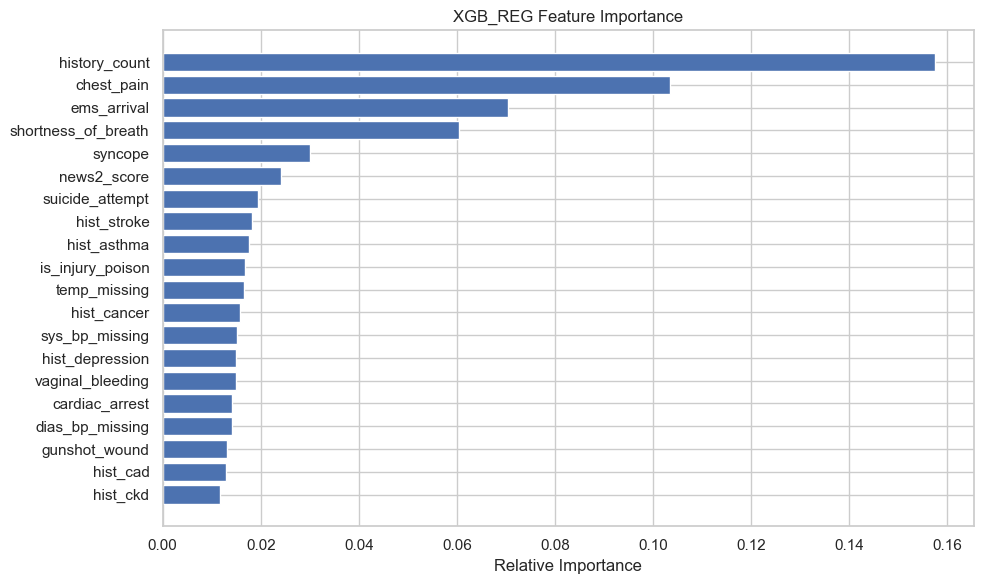

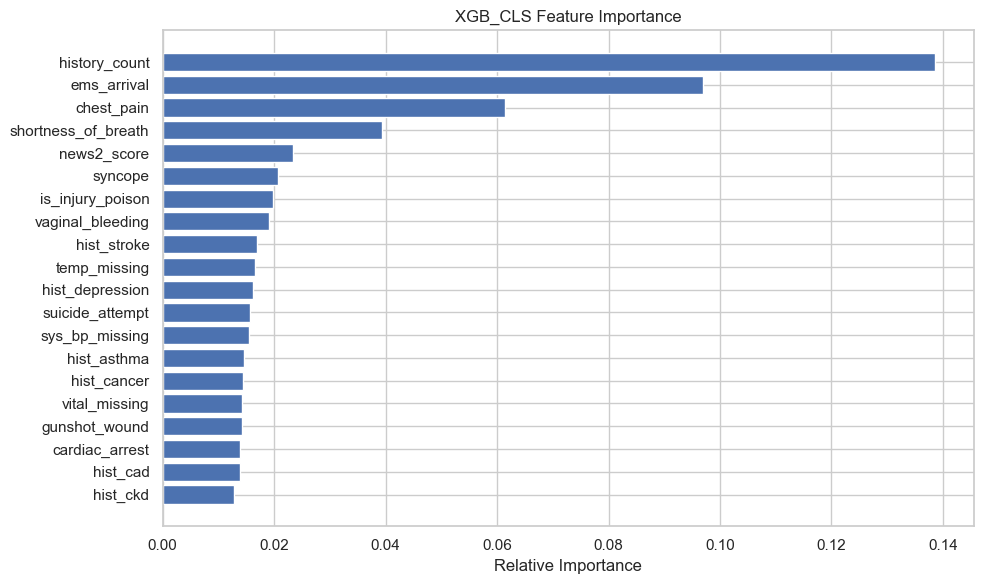

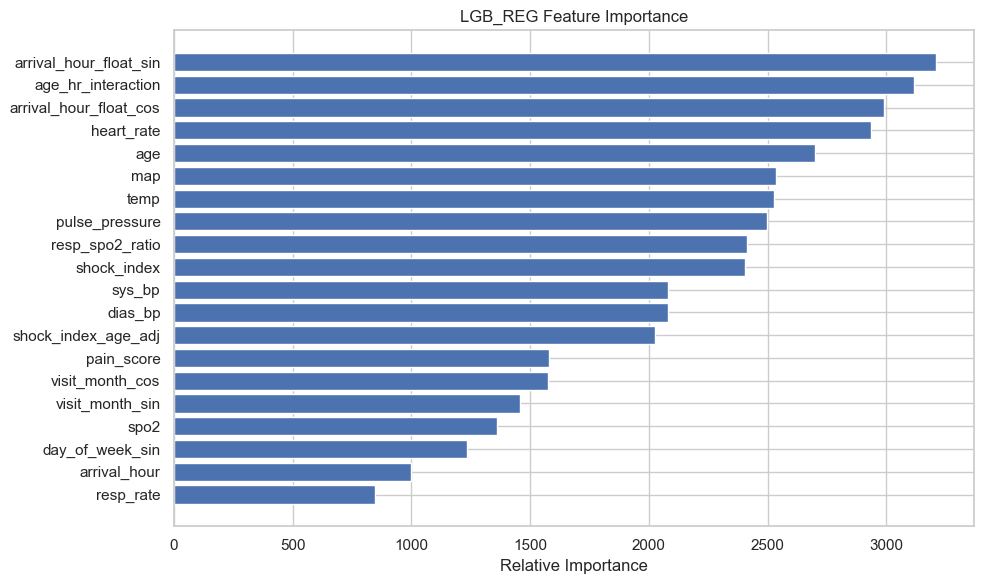

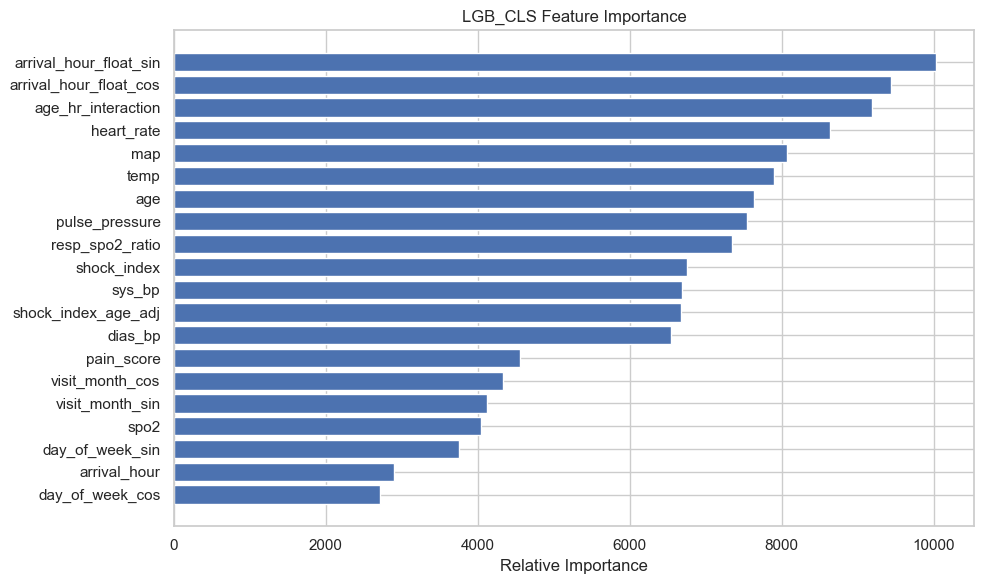

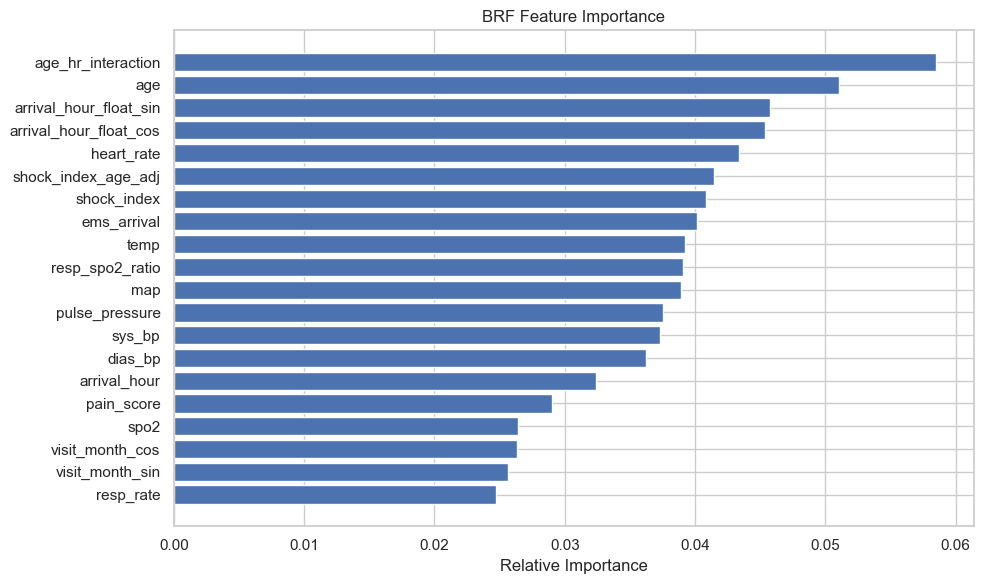

In [4]:
def plot_importance(model, features, title, top_n=20):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'get_booster'): # XGBoost scikit-learn wrapper
        imp = model.feature_importances_
    else:
        return
    
    # Handle mismatch in feature length (e.g. if model was trained on different subset)
    if len(imp) != len(features):
        print(f"Warning: Mismatch in feature length for {title}. Model has {len(imp)}, features list has {len(features)}.")
        # Try to use model's own feature names if available
        if hasattr(model, 'feature_names_in_'):
            features = model.feature_names_in_
            imp = model.feature_importances_
        elif hasattr(model, 'feature_name_'): # LGBM
            features = model.feature_name_
            imp = model.feature_importances_
            
    indices = np.argsort(imp)[-top_n:]
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.barh(range(len(indices)), imp[indices], align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()

for m_name in ['xgb_reg', 'xgb_cls', 'lgb_reg', 'lgb_cls', 'brf']:
    if m_name in models:
        plot_importance(models[m_name], X_tabular.columns, f"{m_name.upper()} Feature Importance")


## 4. SHAP Value Analysis
SHAP provides a unified measure of feature contribution by considering interactions. We use a sample for efficiency.


Calculating SHAP values for xgb_reg...


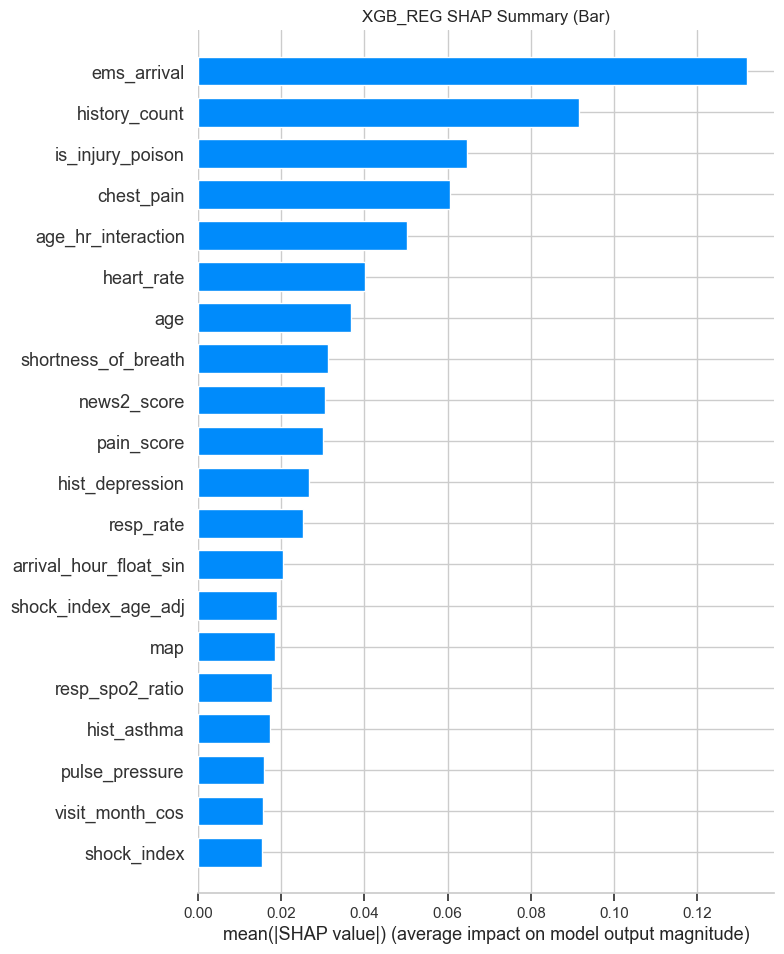

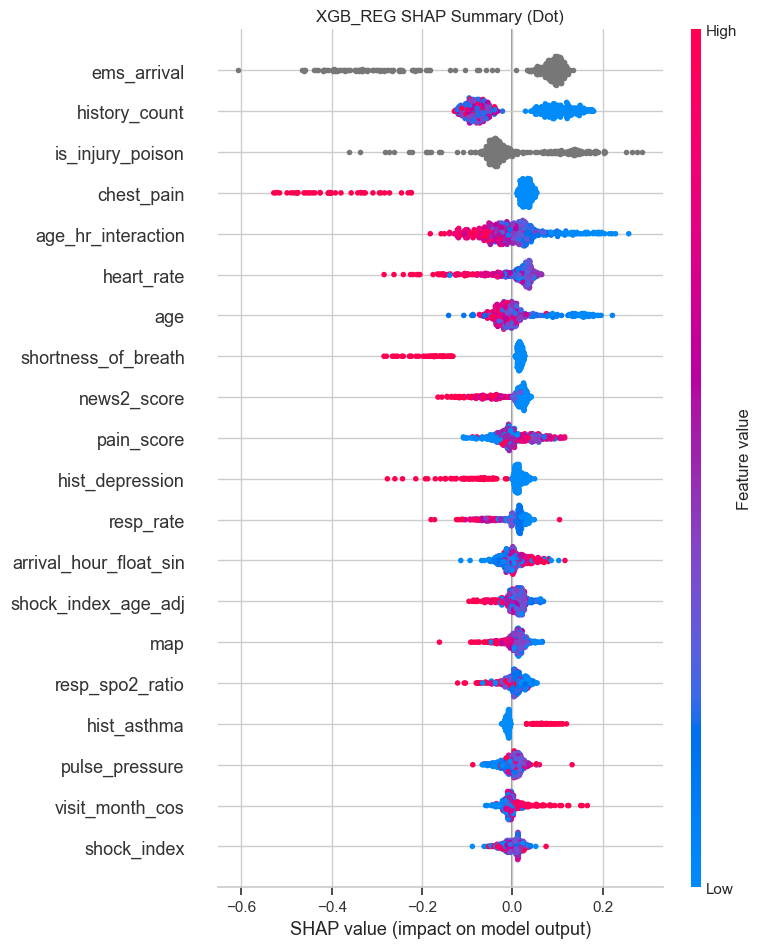


Calculating SHAP values for xgb_cls...


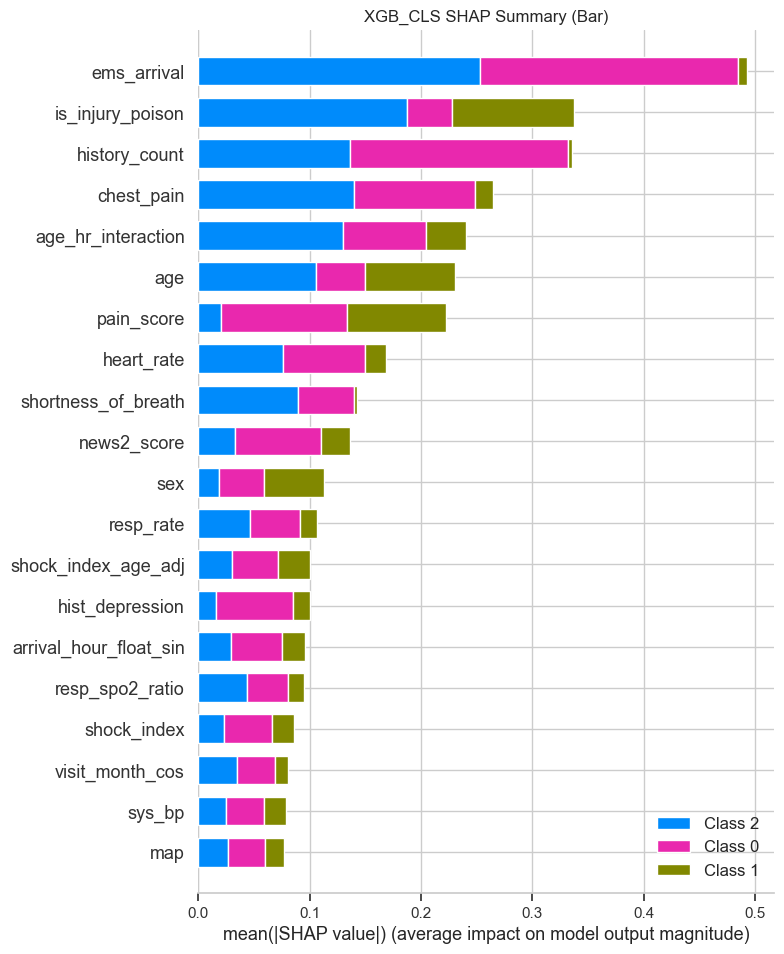

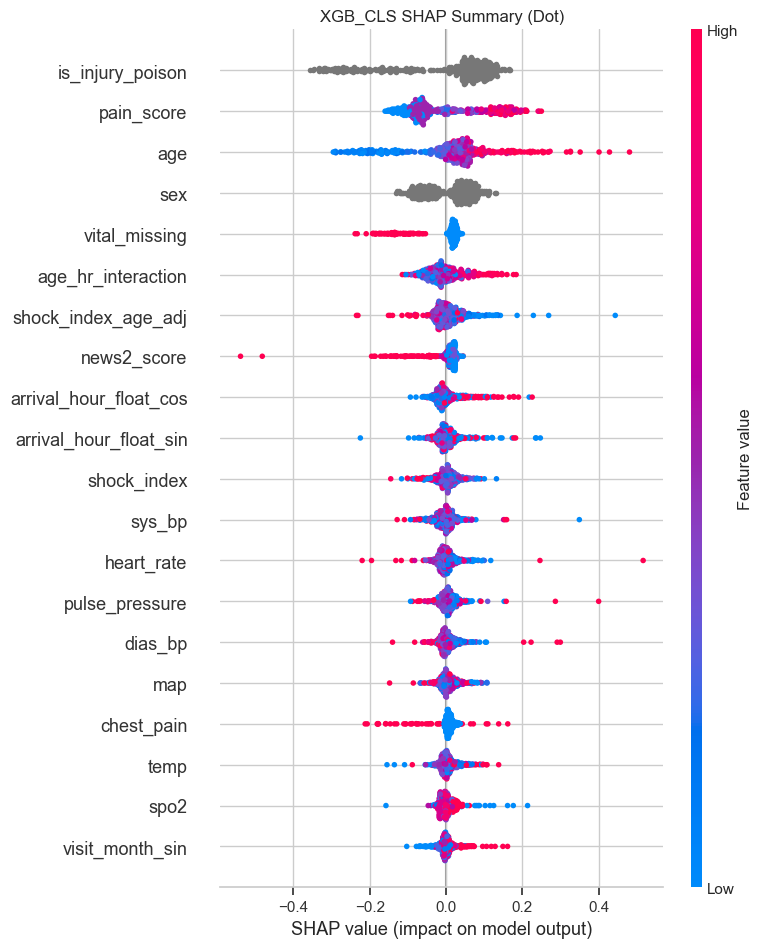


Calculating SHAP values for lgb_reg...


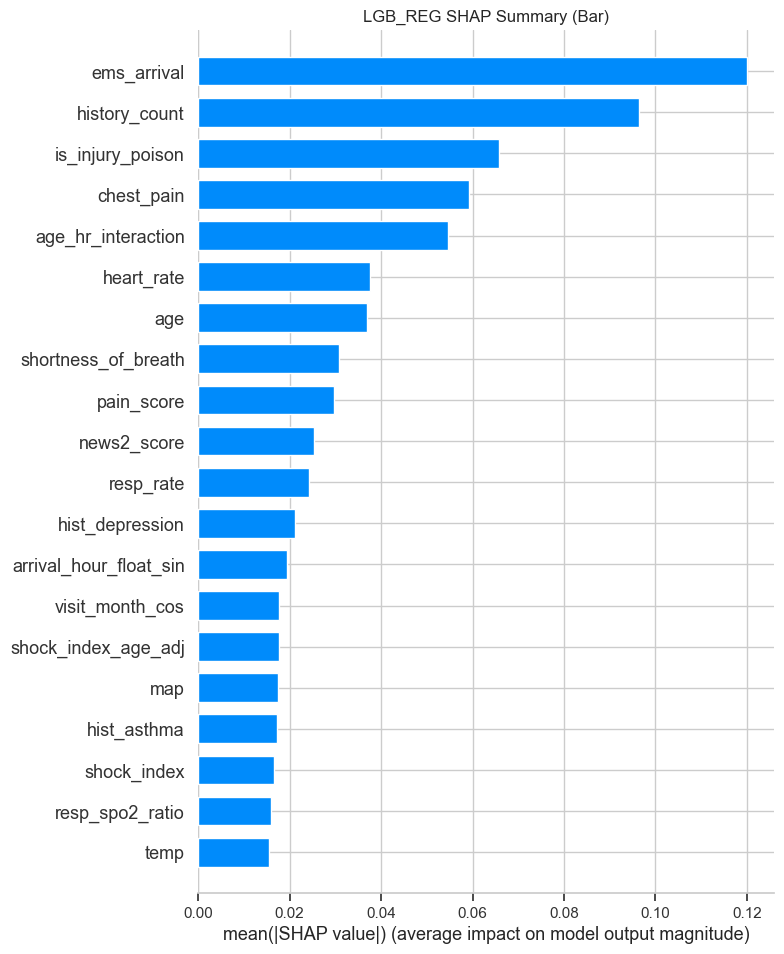

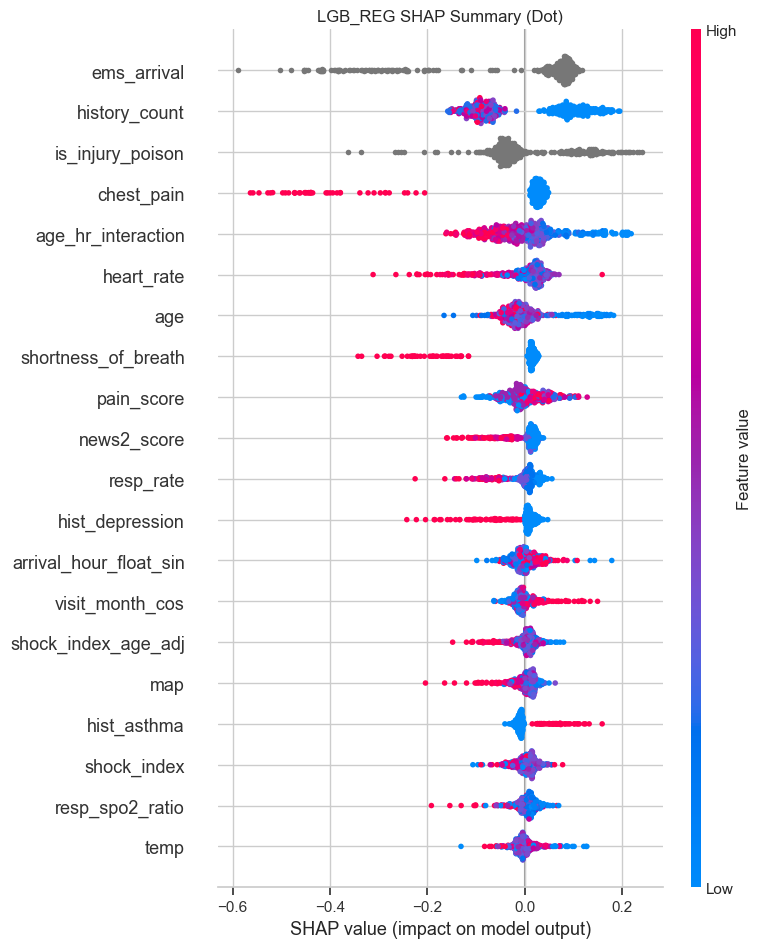


Calculating SHAP values for lgb_cls...


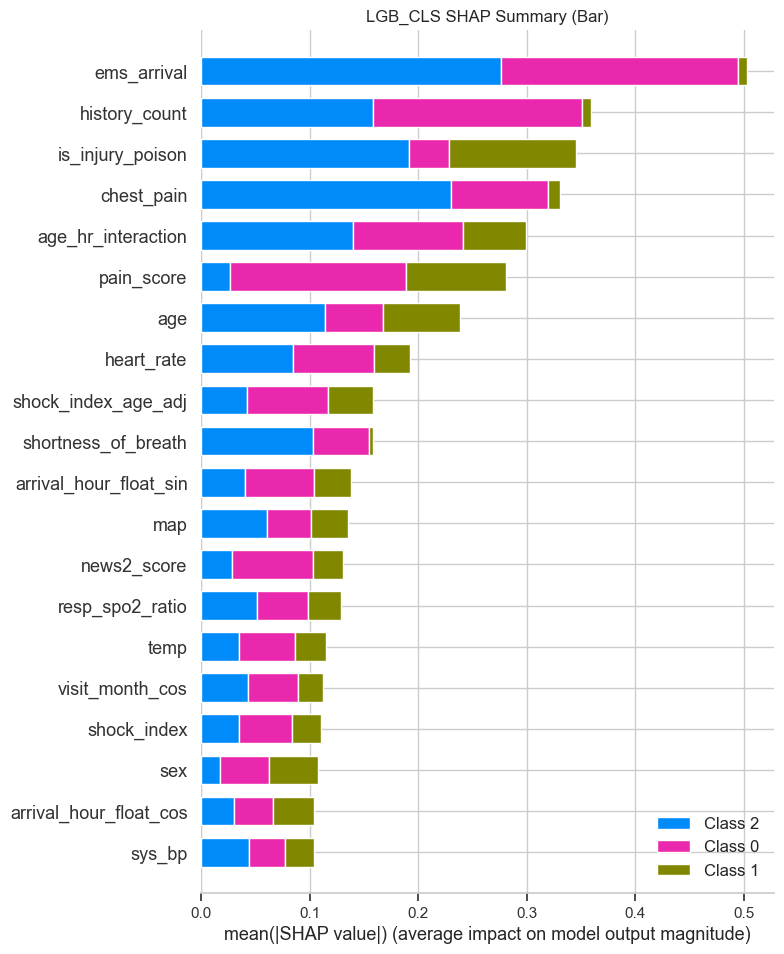

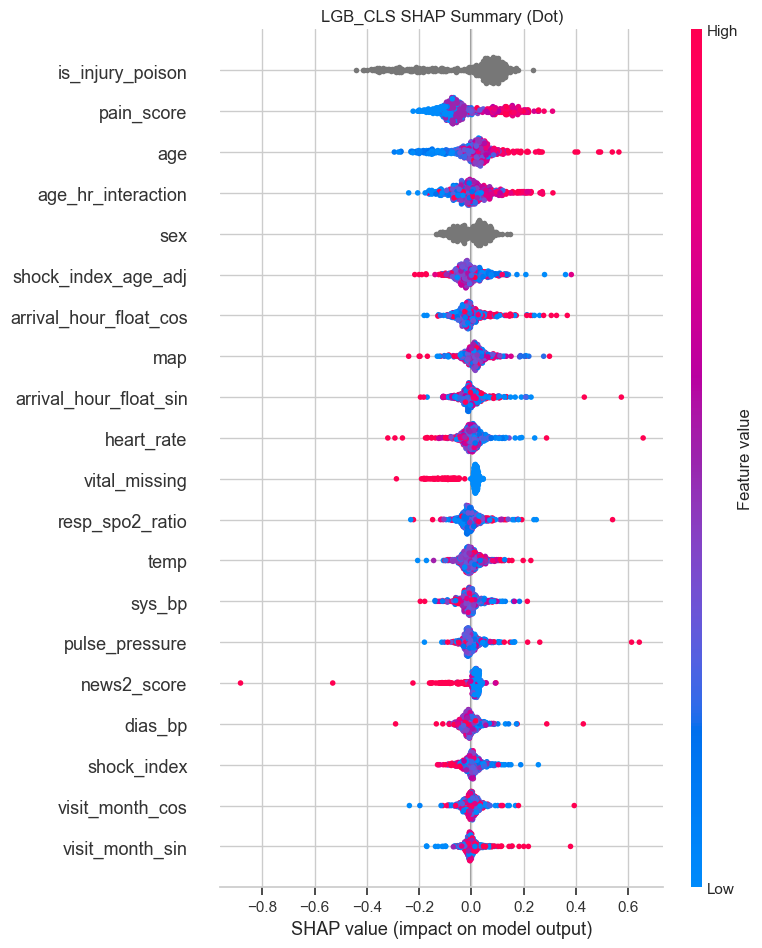


Calculating SHAP values for brf...
Error calculating SHAP for brf: could not convert string to float: 'No'


In [5]:
sample_idx = np.random.choice(len(X_tabular), min(500, len(X_tabular)), replace=False)
X_sample = X_tabular.iloc[sample_idx]

for m_name in ['xgb_reg', 'xgb_cls', 'lgb_reg', 'lgb_cls', 'brf']:
    if m_name not in models:
        continue

    print(f"\nCalculating SHAP values for {m_name}...")
    try:
        model = models[m_name]
        
        # Use CPU-based TreeExplainer instead of GPU
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        # Normalize multiclass format for plotting
        if isinstance(shap_values, list):
            bar_values = shap_values
            dot_values = shap_values[1 if len(shap_values) > 1 else 0]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            per_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
            bar_values = per_class
            dot_values = per_class[1 if len(per_class) > 1 else 0]
        else:
            bar_values = shap_values
            dot_values = shap_values

        plt.figure()
        shap.summary_plot(bar_values, X_sample, plot_type="bar", show=False)
        plt.title(f"{m_name.upper()} SHAP Summary (Bar)")
        plt.show()

        plt.figure()
        shap.summary_plot(dot_values, X_sample, show=False)
        plt.title(f"{m_name.upper()} SHAP Summary (Dot)")
        plt.show()

    except Exception as e:
        print(f"Error calculating SHAP for {m_name}: {e}")
